In [ ]:
# Load required libraries
library(rugarch)
library(ggplot2)
library(gridExtra)
library(lubridate)

# Read OHLC data from CSV
data <- read.csv("/home/qa/runtime/data/analysis_out/reliance.csv", 
  colClasses = c("Date" = "Date",
    "Open" = "numeric",
    "High" = "numeric",
    "Low" = "numeric",
    "Close" = "numeric",
    "Volume" = "numeric",
    "Dividends" = "numeric",
    "Stock.Splits" = "numeric"))

# Convert to proper date format if needed
data$Date <- parse_date_time(data$Date, orders = c("ymd", "dmy", "mdy"))

# Extract closing prices
price_data <- data$Close
price_data <- na.omit(price_data)

# Set parameters
train_size <- floor(0.8 * length(price_data))  # 80% training, 20% test
test_data <- price_data[(train_size+1):length(price_data)]
n_forecasts <- length(test_data)

# Initialize vectors
predicted_prices <- numeric(n_forecasts)
errors <- numeric(n_forecasts)

# GARCH specification
garch_spec <- ugarchspec(
  variance.model = list(model = "sGARCH", garchOrder = c(1,1)),
  mean.model = list(armaOrder = c(0,0)),
  distribution.model = "std"
)

# Forecasting loop
for(t in 1:n_forecasts) {
  current_window <- price_data[1:(train_size + t - 1)]
  returns_window <- diff(log(current_window)) * 100
  
  garch_fit <- ugarchfit(garch_spec, returns_window)
  garch_forecast <- ugarchforecast(garch_fit, n.ahead = 1)
  
  predicted_return <- as.numeric(garch_forecast@forecast$seriesFor)
  last_price <- tail(current_window, 1)
  predicted_prices[t] <- last_price * exp(predicted_return/100)
  
  errors[t] <- (test_data[t] - predicted_prices[t])/test_data[t] * 100
}

# Create dataframe for plotting with actual dates
plot_data <- data.frame(
  Date = data$Date[(train_size+1):(train_size + n_forecasts)],
  Actual = test_data,
  Predicted = predicted_prices,
  Error = errors
)

# Plot 1: Actual vs Predicted prices with OHLC elements
p1 <- ggplot(plot_data, aes(x = Date)) +
  geom_line(aes(y = Actual, color = "Actual"), linewidth = 0.8) +
  geom_line(aes(y = Predicted, color = "Predicted"), linewidth = 0.8, linetype = "dashed") +
  geom_segment(data = data[(train_size+1):(train_size + n_forecasts)], 
               aes(x = Date, xend = Date, y = Low, yend = High),
               color = "darkgray", linewidth = 0.3) +
  scale_color_manual(values = c("Actual" = "black", "Predicted" = "red")) +
  labs(title = "Actual vs Predicted Prices with OHLC Range",
       y = "Price",
       color = "Series") +
  theme_minimal() +
  scale_x_date(date_labels = "%b %Y", date_breaks = "3 months")

# Plot 2: Forecast Error Percentage with annotations
p2 <- ggplot(plot_data, aes(x = Date, y = Error)) +
  geom_line(color = "blue", linewidth = 0.5) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "darkgray") +
  geom_point(data = subset(plot_data, abs(Error) > quantile(abs(Error), 0.95)),
             aes(color = "Extreme Errors"), size = 2) +
  labs(title = "Forecast Error Percentage",
       y = "Error (%)",
       color = "Threshold") +
  scale_color_manual(values = "red") +
  theme_minimal() +
  scale_x_date(date_labels = "%b %Y", date_breaks = "3 months")

# Arrange plots
grid.arrange(p1, p2, ncol = 1, heights = c(2, 1))

# Performance metrics
cat("Enhanced Forecast Metrics:\n")
cat("Median Absolute Error (%):", round(median(abs(plot_data$Error)), 2), "\n")
cat("Error Standard Deviation (%):", round(sd(plot_data$Error), 2), "\n")
cat("95% Error Quantile (%):", round(quantile(abs(plot_data$Error), 0.95), 2), "\n")
cat("Directional Accuracy (%):", 
    round(mean(sign(diff(plot_data$Actual)) == sign(diff(plot_data$Predicted)))*100, 2), "\n")



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




ERROR: Error in `[.data.frame`(data, (train_size + 1):(train_size + n_forecasts)): undefined columns selected



Attaching package: ‘dplyr’


The following object is masked from ‘package:gridExtra’:

    combine


The following object is masked from ‘package:ggplot2’:

    vars


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union





Advanced Performance Metrics:
MASE: 1 
Theil's U: 1 
Directional Accuracy: 46.2 %


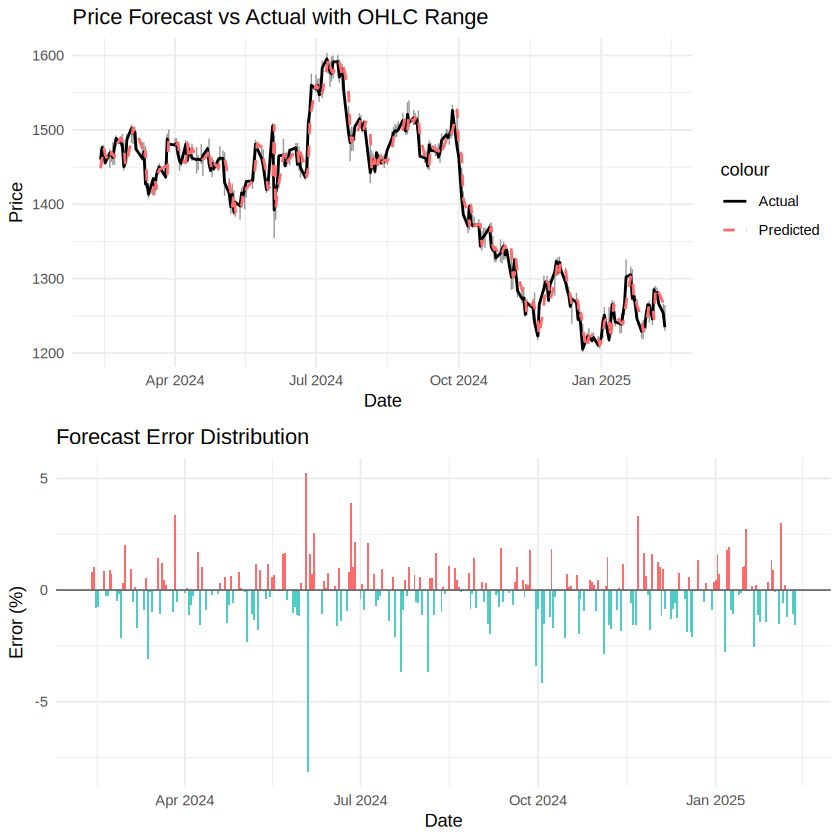

In [ ]:
# Load required libraries
library(dplyr) 
library(rugarch)
library(ggplot2)
library(gridExtra)
library(lubridate)

# Read and clean data
data <- read.csv("/home/qa/runtime/data/analysis_out/garch/reliance.csv")
data <- mutate(data, Date = as.Date(Date))
data <- filter(data, complete.cases(Close))

# Extract cleaned price series
price_data <- data$Close
train_size <- floor(0.8 * nrow(data))
test_size <- nrow(data) - train_size

# Initialize vectors
predicted_prices <- numeric(test_size)
errors <- numeric(test_size)

# GARCH specification
garch_spec <- ugarchspec(
  variance.model = list(model = "sGARCH", garchOrder = c(1,1)),
  mean.model = list(armaOrder = c(0,0)),
  distribution.model = "std"
)

# Forecasting loop
for(t in 1:test_size) {
  current_window <- price_data[1:(train_size + t - 1)]
  returns_window <- diff(log(current_window)) * 100
  
  garch_fit <- ugarchfit(garch_spec, returns_window)
  garch_forecast <- ugarchforecast(garch_fit, n.ahead = 1)
  
  predicted_return <- as.numeric(garch_forecast@forecast$seriesFor)
  last_price <- tail(current_window, 1)
  predicted_prices[t] <- last_price * exp(predicted_return/100)
  
  errors[t] <- (data$Close[train_size + t] - predicted_prices[t])/data$Close[train_size + t] * 100
}

# Create plotting dataframe
plot_data <- data.frame(
  Date = data$Date[(train_size + 1):nrow(data)],
  Actual = data$Close[(train_size + 1):nrow(data)],
  Predicted = predicted_prices,
  Error = errors
)

# Plot 1: Price comparison with OHLC bars
p1 <- ggplot(plot_data, aes(x = Date)) +
  geom_segment(data = data[(train_size + 1):nrow(data),], 
               aes(x = Date, xend = Date, y = Low, yend = High),
               color = "gray60", linewidth = 0.4) +
  geom_line(aes(y = Actual, color = "Actual"), linewidth = 0.8) +
  geom_line(aes(y = Predicted, color = "Predicted"), linewidth = 0.8, linetype = "dashed") +
  scale_color_manual(values = c("Actual" = "black", "Predicted" = "#FF6B6B")) +
  labs(title = "Price Forecast vs Actual with OHLC Range",
       y = "Price") +
  theme_minimal() +
  scale_x_date(date_labels = "%b %Y")

# Plot 2: Error analysis
p2 <- ggplot(plot_data, aes(x = Date, y = Error)) +
  geom_bar(aes(fill = Error > 0), stat = "identity", width = 1) +
  scale_fill_manual(values = c("#4ECDC4", "#FF6B6B")) +
  geom_hline(yintercept = 0, color = "gray40") +
  labs(title = "Forecast Error Distribution",
       y = "Error (%)") +
  theme_minimal() +
  theme(legend.position = "none") +
  scale_x_date(date_labels = "%b %Y")

grid.arrange(p1, p2, ncol = 1)

# Calculate Advanced Metrics
cat("\nAdvanced Performance Metrics:\n")

# 1. MASE Calculation (using absolute price errors)
absolute_errors <- abs(plot_data$Actual - plot_data$Predicted)
naive_forecast_errors <- abs(diff(plot_data$Actual))  # One-day naive forecast
mase_value <- mean(absolute_errors[-1]) / mean(naive_forecast_errors)
cat("MASE:", round(mase_value, 2), "\n")

# 2. Theil's U Statistic (correct formula implementation)
forecast_errors <- plot_data$Actual - plot_data$Predicted
actual_changes <- c(NA, diff(plot_data$Actual))

theils_numerator <- mean(forecast_errors^2, na.rm = TRUE)
theils_denominator <- mean(actual_changes^2, na.rm = TRUE)
theils_u <- sqrt(theils_numerator) / sqrt(theils_denominator)
cat("Theil's U:", round(theils_u, 2), "\n")

# 3. Directional Accuracy (correct implementation)
actual_directions <- sign(diff(plot_data$Actual))
predicted_directions <- sign(diff(plot_data$Predicted))
direction_accuracy <- mean(actual_directions == predicted_directions, na.rm = TRUE)
cat("Directional Accuracy:", round(direction_accuracy * 100, 1), "%\n")

In [ ]:
# Load required libraries
library(dplyr) 
library(rugarch)
library(ggplot2)
library(gridExtra)
library(lubridate)
library(TTR)       # For technical indicators
library(MSwM)      # For Markov Switching Model

# Read and clean data
data <- read.csv("/home/qa/runtime/data/analysis_out/garch/reliance.csv")
data <- mutate(data, Date = as.Date(Date))
data <- filter(data, complete.cases(Close))

data <- data[, c("Date", "Open", "High", "Low", "Close", "Volume")]

print(names(data))
print(head(data))   # See first few rows of data

# Ensure column names exist
if (!all(c("High", "Low", "Close") %in% names(data))) {
  stop("CSV file is missing required columns: High, Low, Close")
}

sum(is.na(data))  # Count total missing values

# Add technical indicators (ADX & RSI)
adx_values <- ADX(data[, c("High", "Low", "Close")], n = 14)  # Compute ADX
data$ADX <- adx_values[, "ADX"]  # Extract only the ADX column

data$RSI <- RSI(data$Close, n = 14)

# Remove NA values (generated by indicators)
data <- na.omit(data)

# Print first few rows to verify
print(head(data))

# Extract cleaned price series
price_data <- data$Close
train_size <- floor(0.8 * nrow(data))
test_size <- nrow(data) - train_size

# Rolling window size (500 days)
window_size <- 500

# Initialize vectors
predicted_prices <- numeric(test_size)
errors <- numeric(test_size)
conf_upper <- numeric(test_size)
conf_lower <- numeric(test_size)

# Prepare external regressors
external_regressors <- as.matrix(data[, c("ADX", "RSI")])

# EGARCH Specification 
garch_spec <- ugarchspec(
  variance.model = list(model = "eGARCH", garchOrder = c(1,1)), 
  mean.model = list(armaOrder = c(1,0), include.mean = TRUE),  
  distribution.model = "std"
)

# Forecasting loop (rolling window approach)
for(t in 1:test_size) {
  # Define rolling training window
  start_idx <- max(1, train_size + t - window_size)
  current_window <- price_data[start_idx:(train_size + t - 1)]
  
  # Ensure log returns before fitting GARCH
  returns_window <- diff(log(current_window)) * 100  # Convert to log returns
  
  # Fit GARCH model
  garch_fit <- ugarchfit(garch_spec, returns_window)
  
  # Forecast next-day return using mean forecast
  garch_forecast <- ugarchforecast(garch_fit, n.ahead = 1)
  predicted_return <- as.numeric(garch_forecast@forecast$seriesFor[1])  # Use mean forecast
  
  # Confidence interval
  conf_int <- garch_forecast@forecast$sigmaFor[1]  # Volatility forecast

  if (var(returns_window) < 1e-6) {
    stop("Returns variance is too small, MSM model may fail. Increase rolling window.")
  }

  # Apply MSM on residuals
  msm_model <- msmFit(lm(returns_window ~ 1),
   k = 2,
   sw = rep(TRUE, 2),
   control = list(parallel = FALSE, maxiter = 1000)  # Allow more iterations
  )

  # Check available slots
  #str(msm_model@Fit)
  
  # Extract regime probabilities
  regime_probs <- msm_model@Fit@filtProb
  
  #print(head(regime_probs))

  # Adjust forecast using MSM regime probabilities
  predicted_return <- predicted_return * (1 + regime_probs[nrow(regime_probs),1] - regime_probs[nrow(regime_probs),2])

  # Convert predicted return back to price
  last_price <- tail(current_window, 1)
  predicted_prices[t] <- last_price * exp(predicted_return/100)
  
  # Compute prediction error
  errors[t] <- (data$Close[train_size + t] - predicted_prices[t]) / data$Close[train_size + t] * 100

  # Store confidence intervals
  conf_upper[t] <- predicted_prices[t] + conf_int
  conf_lower[t] <- predicted_prices[t] - conf_int
}

# Create DataFrame for visualization
plot_data <- data.frame(
  Date = data$Date[(train_size + 1):nrow(data)],
  Actual = data$Close[(train_size + 1):nrow(data)],
  Predicted = predicted_prices,
  Error = errors,
  Upper = conf_upper,
  Lower = conf_lower
)

# Plot 1: Actual vs. Predicted Prices with Confidence Bands
p1 <- ggplot(plot_data, aes(x = Date)) +
  geom_ribbon(aes(ymin = Lower, ymax = Upper), fill = "gray70", alpha = 0.3) +
  geom_segment(data = data[(train_size + 1):nrow(data),], 
               aes(x = Date, xend = Date, y = Low, yend = High),
               color = "gray60", linewidth = 0.4) +
  geom_line(aes(y = Actual, color = "Actual"), linewidth = 0.8) +
  geom_line(aes(y = Predicted, color = "Predicted"), linewidth = 0.8, linetype = "dashed") +
  scale_color_manual(values = c("Actual" = "black", "Predicted" = "#FF6B6B")) +
  labs(title = "Price Forecast vs Actual with Confidence Bands",
       y = "Price") +
  theme_minimal() +
  scale_x_date(date_labels = "%b %Y")

# Plot 2: Forecast Error Distribution
p2 <- ggplot(plot_data, aes(x = Date, y = Error)) +
  geom_bar(aes(fill = Error > 0), stat = "identity", width = 1) +
  scale_fill_manual(values = c("#4ECDC4", "#FF6B6B")) +
  geom_hline(yintercept = 0, color = "gray40") +
  labs(title = "Forecast Error Distribution",
       y = "Error (%)") +
  theme_minimal() +
  theme(legend.position = "none") +
  scale_x_date(date_labels = "%b %Y")

grid.arrange(p1, p2, ncol = 1)

# 📊 Advanced Performance Metrics
cat("\nAdvanced Performance Metrics:\n")

# 1️⃣ MASE Calculation (Mean Absolute Scaled Error)
absolute_errors <- abs(plot_data$Actual - plot_data$Predicted)
naive_forecast_errors <- abs(diff(plot_data$Actual))  # One-day naive forecast
mase_value <- mean(absolute_errors[-1]) / mean(naive_forecast_errors)
cat("MASE:", round(mase_value, 2), "\n")

# 2️⃣ Theil's U Statistic
forecast_errors <- plot_data$Actual - plot_data$Predicted
actual_changes <- c(NA, diff(plot_data$Actual))

theils_numerator <- mean(forecast_errors^2, na.rm = TRUE)
theils_denominator <- mean(actual_changes^2, na.rm = TRUE)

# Fix for zero division
if (theils_denominator == 0) {
  theils_u <- NA
} else {
  theils_u <- sqrt(theils_numerator) / sqrt(theils_denominator)
}

cat("Theil's U:", round(theils_u, 2), "\n")

# 3️⃣ Directional Accuracy
actual_directions <- sign(diff(plot_data$Actual))
predicted_directions <- sign(diff(plot_data$Predicted))

valid_idx <- !is.na(actual_directions) & !is.na(predicted_directions)
direction_accuracy <- mean(actual_directions[valid_idx] == predicted_directions[valid_idx], na.rm = TRUE)

cat("Directional Accuracy:", round(direction_accuracy * 100, 1), "%\n")

[1] "Date"   "Open"   "High"   "Low"    "Close"  "Volume"
        Date     Open     High      Low    Close   Volume
1 2020-02-11 645.1525 653.5322 644.1050 647.5372 13999816
2 2020-02-12 649.0526 657.3878 648.5400 655.3597 13533565
3 2020-02-13 658.6805 658.6805 651.9276 657.0758 13565659
4 2020-02-14 658.4575 669.2442 647.6931 663.0709 21227841
5 2020-02-17 663.6949 671.3392 657.1426 658.9033 13149130
6 2020-02-18 657.8557 657.8557 649.6097 654.0670 11127161


[1] 0

         Date     Open     High      Low    Close   Volume      ADX      RSI
28 2020-03-23 408.3796 423.4453 390.3052 394.0493 40670949 69.62848 25.51163
29 2020-03-24 414.5307 432.3600 399.2867 420.5035 45734887 68.87205 31.71913
30 2020-03-25 429.5964 513.2826 429.3513 482.3934 73130298 65.01075 43.56766
31 2020-03-26 488.4331 497.8380 464.6087 475.2394 45744488 61.42527 42.64644
32 2020-03-27 488.0765 493.5590 466.3248 474.9720 41657940 58.09589 42.61017
33 2020-03-30 463.8287 479.0728 454.6466 459.3045 30229866 55.29473 40.44017


ERROR: Error in solve.default(res$Hessian): Lapack routine dgesv: system is exactly singular: U[5,5] = 0
